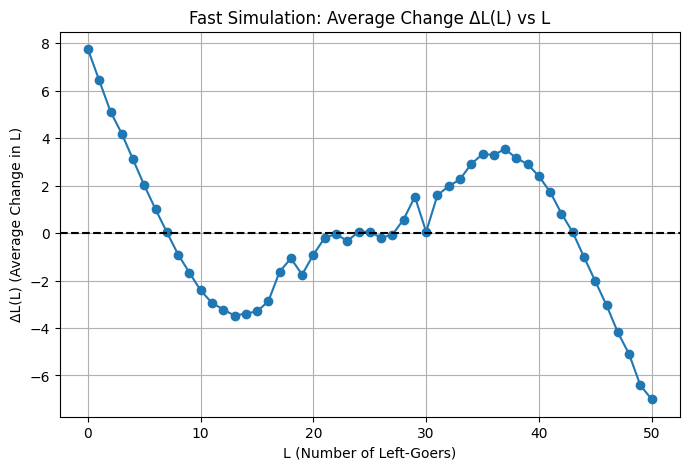

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
C = 0.5
v = 0.01
r = 0.045
N = 50
P = 0.15
T_warmup = 100
T_measure = 20
runs = 5000

# Preallocate results
delta_sum = np.zeros(N + 1)
count = np.zeros(N + 1)

# Simulation
for run in range(runs):
    # Initialize positions and directions
    positions = np.random.uniform(0, C, N)
    directions = np.random.choice([-1, 1], N)

    L_prev = np.count_nonzero(directions == -1)

    for t in range(T_warmup + T_measure):
        # Compute pairwise circular distances (vectorized)
        pos_diff = positions[:, None] - positions
        distances = np.abs(pos_diff)
        distances = np.minimum(distances, C - distances)

        # Count influence from neighbors within r
        influence = np.zeros(N)
        for i in range(N):
            neighbors = distances[i] <= r
            local_sum = np.sum(directions[neighbors])
            if np.random.rand() < P:
                influence[i] = -directions[i]
            elif local_sum != 0:
                influence[i] = np.sign(local_sum)
            else:
                influence[i] = directions[i]

        directions = influence.astype(int)
        positions = (positions + v * directions) % C

        L_curr = np.count_nonzero(directions == -1)

        if t >= T_warmup:
            delta = L_curr - L_prev
            delta_sum[L_prev] += delta
            count[L_prev] += 1
        L_prev = L_curr

# Finalize results
nonzero_mask = count > 0
L_vals = np.arange(N + 1)[nonzero_mask]
avg_deltaL = delta_sum[nonzero_mask] / count[nonzero_mask]

# Save to file
with open("L_of_L.txt", "w") as f:
    for L, dL in zip(L_vals, avg_deltaL):
        f.write(f"{L} {dL}\n")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(L_vals, avg_deltaL, marker='o')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("L (Number of Left-Goers)")
plt.ylabel("ΔL(L) (Average Change in L)")
plt.title("Fast Simulation: Average Change ΔL(L) vs L")
plt.grid(True)
plt.show()


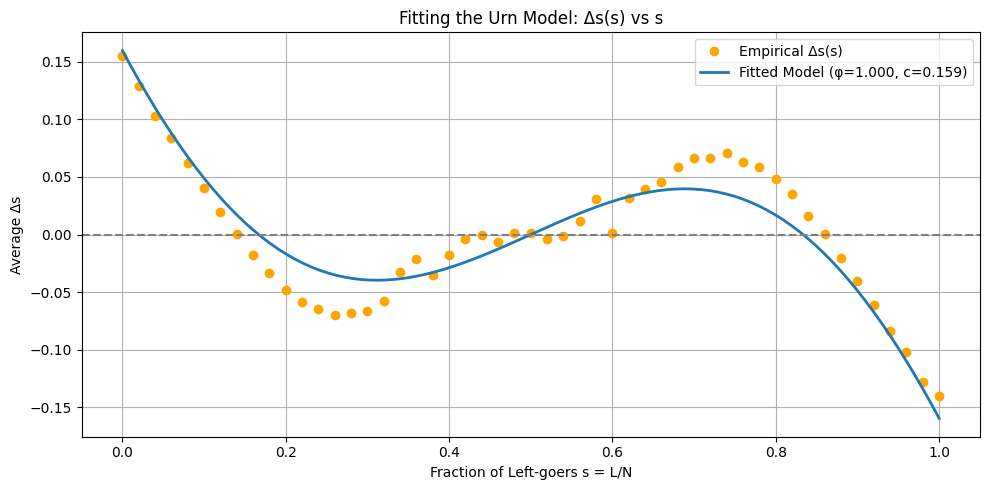

In [9]:

from scipy.optimize import curve_fit
# Load dataset: should contain L and ΔL values
data = np.loadtxt("L_of_L.txt")  
L_vals = data[:, 0].astype(int)
delta_L_vals = data[:, 1]

# Convert to s and Δs
s_vals = L_vals / N
delta_s_empirical = delta_L_vals / N

# Define theoretical urn model
def delta_s_model(s, phi, c):
    P_FB = phi * np.sin(np.pi * s)
    return 4 * c * (P_FB - 0.5) * (s - 0.5)

# Fit the model only on valid data (all entries in the file)
popt, _ = curve_fit(delta_s_model, s_vals, delta_s_empirical, bounds=([0, 0], [1, 10]))
phi_opt, c_opt = popt

# Generate fit curve
s_fit = np.linspace(0, 1, 200)
delta_s_fit = delta_s_model(s_fit, phi_opt, c_opt)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(s_vals, delta_s_empirical, 'o', label='Empirical Δs(s)', color='orange')
plt.plot(s_fit, delta_s_fit, label=f'Fitted Model (φ={phi_opt:.3f}, c={c_opt:.3f})', linewidth=2)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Fitting the Urn Model: Δs(s) vs s")
plt.xlabel("Fraction of Left-goers s = L/N")
plt.ylabel("Average Δs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
